# Load Libraries & Dataset

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
# Load dataset
df = pd.read_csv("bmw_global_sales_2018_2025.csv")

df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


# Task 1 Identify data quality issues in the dataset.

In [61]:
# Check basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   str    
 3   Model             3072 non-null   str    
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), str(2)
memory usage: 264.1 KB


In [62]:
# Check missing values
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [63]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [64]:
# Summary statistics
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


# Task 2 Apply one missing value strategy and explain why.

In [65]:
# Select numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols

Index(['Year', 'Month', 'Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR',
       'BEV_Share', 'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index'],
      dtype='str')

In [66]:
# Apply mean imputation
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [67]:
# Verify missing values are handled
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

Mean imputation was used to handle missing values in the numerical features.
This method replaces missing values with the average of the column. It helps keep all records in the dataset and prevents data loss. Since the dataset mainly contains continuous variables such as sales, and the number of missing values is small, using the mean is a simple and reasonable choice.

# Task 3 Detect and handle outliers using IQR.

In [68]:
# Store original shape
original_shape = df.shape

In [69]:
# Define IQR outlier removal function
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

In [70]:
# Apply IQR method to selected columns
df = remove_outliers_iqr(df, "Units_Sold")
df = remove_outliers_iqr(df, "Avg_Price_EUR")

In [71]:
# Print shapes
print("Original shape: ", original_shape)
print("After removing outliers: ", df.shape)

Original shape:  (3072, 11)
After removing outliers:  (3072, 11)


Text(0.5, 1.0, 'Boxplot of Units Sold')

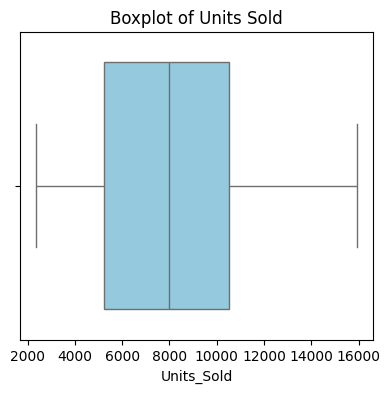

In [72]:
# Plotting Units Sold
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1) # Side-by-side plot
sns.boxplot(x=df['Units_Sold'], color='skyblue')
plt.title("Boxplot of Units Sold")

Text(0.5, 1.0, 'Boxplot of Average Price (EUR)')

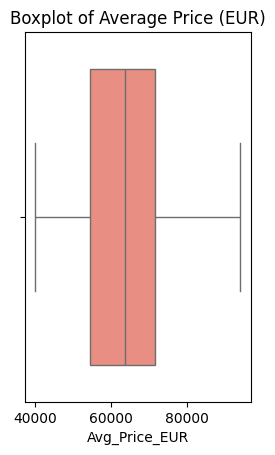

In [73]:
# Plotting Average Price
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Avg_Price_EUR'], color='salmon')
plt.title("Boxplot of Average Price (EUR)")

# Task 4 Normalize numerical features using both Min-Max and Z-score.

In [74]:
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax_scaler.fit_transform(df[num_cols])

df_minmax.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,0.0,0.0,Europe,3 Series,0.402143,0.138395,0.200815,0.109244,0.883501,0.594406,0.163265
1,0.0,0.0,Europe,5 Series,0.583746,0.401497,0.398503,0.142857,0.883501,0.594406,0.163265
2,0.0,0.0,Europe,X3,0.053639,0.341256,0.057868,0.155462,0.883501,0.594406,0.163265
3,0.0,0.0,Europe,X5,0.372442,0.517644,0.300760,0.151261,0.883501,0.594406,0.163265
4,0.0,0.0,Europe,X7,0.450314,0.968620,0.509890,0.210084,0.883501,0.594406,0.163265


In [75]:
zscore_scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[num_cols] = zscore_scaler.fit_transform(df[num_cols])

df_zscore.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,-1.527525,-1.593255,Europe,3 Series,-0.049864,-1.117314,-0.575925,-1.662481,0.836143,0.434677,-1.492111
1,-1.527525,-1.593255,Europe,5 Series,0.724455,-0.148058,0.504866,-1.524762,0.836143,0.434677,-1.492111
2,-1.527525,-1.593255,Europe,X3,-1.535814,-0.369984,-1.357440,-1.473117,0.836143,0.434677,-1.492111
3,-1.527525,-1.593255,Europe,X5,-0.176502,0.279826,-0.029511,-1.490332,0.836143,0.434677,-1.492111
4,-1.527525,-1.593255,Europe,X7,0.155529,1.941204,1.113838,-1.249324,0.836143,0.434677,-1.492111


## Check Correlation Before Applying PCA

In [76]:
# Compute correlation matrix of numerical columns
num_cols = df_zscore.select_dtypes(include=[np.number]).columns
corr_matrix = df_zscore[num_cols].corr()

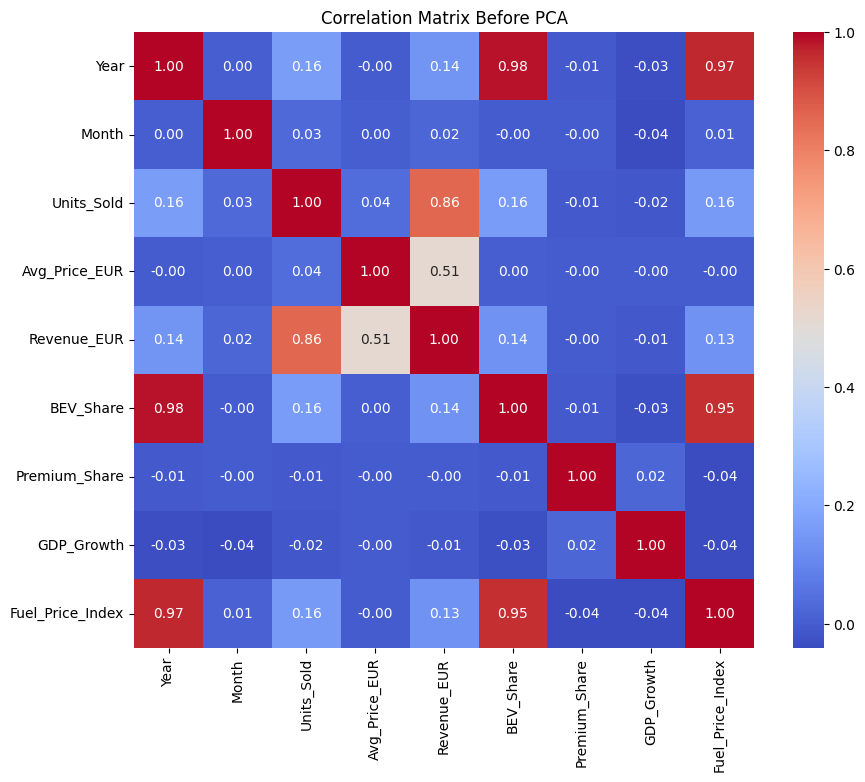

In [77]:
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix Before PCA")
plt.show()

# Task 5 Apply PCA and interpret explained variance.

In [78]:
X = df_zscore[num_cols]

In [79]:
pca = PCA()
X_pca = pca.fit_transform(X)

In [80]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
explained_variance
print("Explained Variance Ratio:", explained_variance)

Explained Variance Ratio: [0.33949784 0.21232059 0.11599553 0.11117293 0.10677467 0.10507007
 0.00559391 0.0020817  0.00149275]


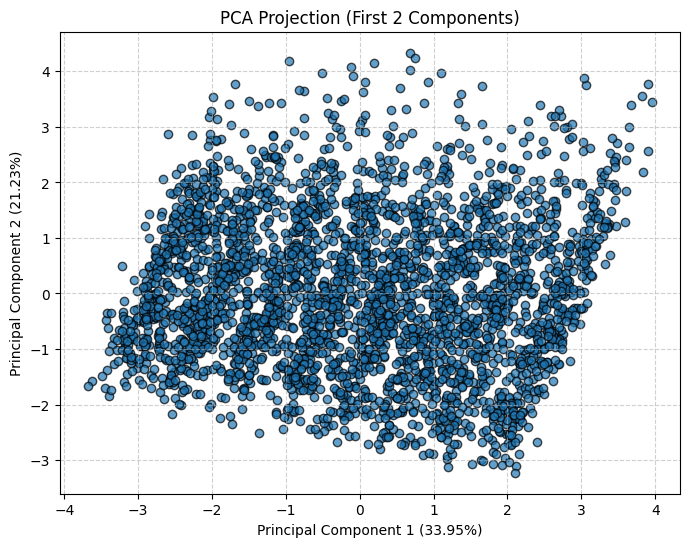

In [81]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k')

plt.title("PCA Projection (First 2 Components)")
plt.xlabel(f"Principal Component 1 ({explained_variance[0]:.2%})")
plt.ylabel(f"Principal Component 2 ({explained_variance[1]:.2%})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()